In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv("D:\Datathon\data\orders.csv")
payments = pd.read_csv("D:\Datathon\data\payments.csv")

orders['order_date'] = pd.to_datetime(orders['order_date'])

df = orders.merge(payments, on='order_id', how='left')

customer_orders = df.groupby('customer_id').agg({
    'order_id': 'count',
    'payment_value': 'sum'
}).reset_index()

customer_orders.rename(columns={'order_id': 'num_orders'}, inplace=True)

def segment_orders(x):
    if x == 1:
        return '1 order'
    elif x <= 3:
        return '2-3 orders'
    else:
        return '4+ orders'

customer_orders['segment'] = customer_orders['num_orders'].apply(segment_orders)

customer_orders

<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10360\2340271412.py:5: SyntaxWarning: invalid escape sequence '\D'
  orders = pd.read_csv("D:\Datathon\data\orders.csv")
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10360\2340271412.py:6: SyntaxWarning: invalid escape sequence '\D'
  payments = pd.read_csv("D:\Datathon\data\payments.csv")


,customer_id,num_orders,payment_value,segment
0,1,6,142803.47,4+ orders
1,2,4,204693.89,4+ orders
2,3,3,52093.47,2-3 orders
3,4,1,10939.06,1 order
4,5,5,64179.86,4+ orders
...,...,...,...,...
90241,157554,1,6263.81,1 order
90242,157555,2,95613.85,2-3 orders
90243,157557,1,5670.72,1 order
90244,157561,22,544675.90,4+ orders


In [2]:
summary = customer_orders.groupby('segment').agg({
    'customer_id': 'count',
    'payment_value': 'sum'
}).reset_index()

summary['revenue_pct'] = summary['payment_value'] / summary['payment_value'].sum()

summary

,segment,customer_id,payment_value,revenue_pct
0,1 order,22358,5.369343e+08,0.034241
1,2-3 orders,20812,1.174891e+09,0.074925
2,4+ orders,47076,1.396904e+10,0.890833


C:\Users\Administrator\AppData\Local\Temp\ipykernel_10360\2427629716.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10360\2427629716.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


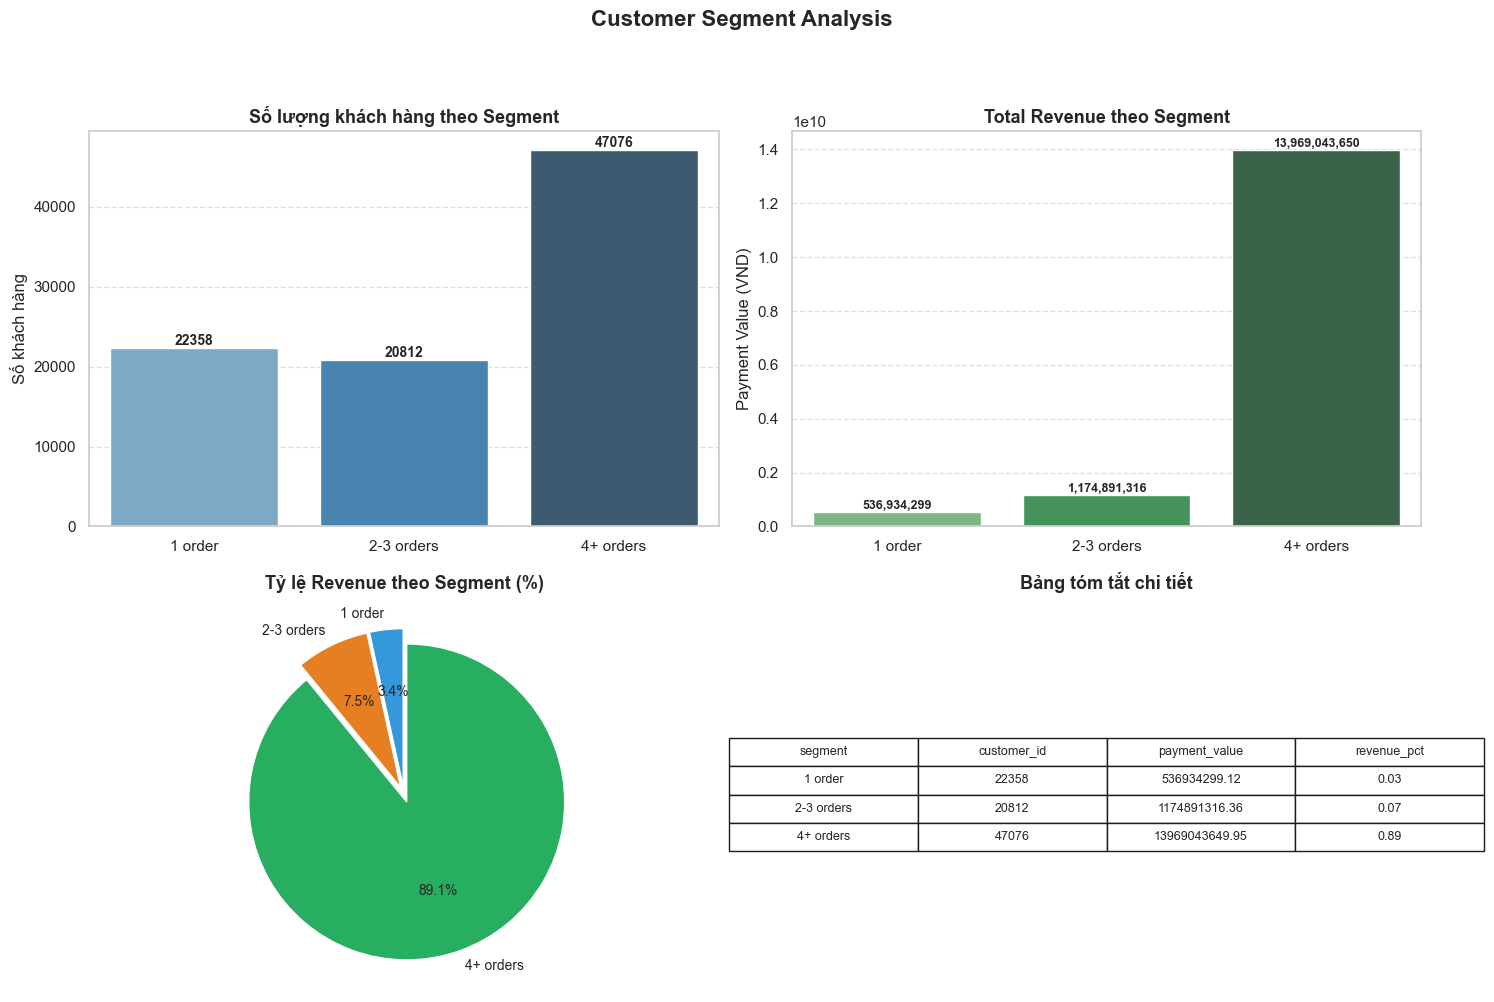

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Đồng bộ style với revenue_overview
sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 12

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Customer Segment Analysis', fontsize=16, fontweight='bold', y=1.02)

# 1. Bar chart - Số lượng khách hàng theo segment
sns.barplot(
    data=summary,
    x='segment',
    y='customer_id',
    ax=axes[0, 0],
    color='#2980b9',
    palette='Blues_d'
)
axes[0, 0].set_title('Số lượng khách hàng theo Segment', fontsize=13, weight='bold')
axes[0, 0].set_ylabel('Số khách hàng', fontsize=12)
axes[0, 0].set_xlabel('')
axes[0, 0].grid(True, linestyle='--', alpha=0.6, axis='y')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold'
    )

# 2. Bar chart - Total Revenue theo segment
sns.barplot(
    data=summary,
    x='segment',
    y='payment_value',
    ax=axes[0, 1],
    color='#27ae60',
    palette='Greens_d'
)
axes[0, 1].set_title('Total Revenue theo Segment', fontsize=13, weight='bold')
axes[0, 1].set_ylabel('Payment Value (VND)', fontsize=12)
axes[0, 1].set_xlabel('')
axes[0, 1].grid(True, linestyle='--', alpha=0.6, axis='y')
for p in axes[0, 1].patches:
    axes[0, 1].annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
        weight='bold'
    )

# 3. Pie chart - Tỷ lệ Revenue (%)
axes[1, 0].pie(
    summary['revenue_pct'],
    labels=summary['segment'],
    autopct='%1.1f%%',
    colors=['#3498db', '#e67e22', '#27ae60', '#9b59b6'][:len(summary)],
    startangle=90,
    explode=[0.05] * len(summary),
    textprops={'fontsize': 10}
)
axes[1, 0].set_title('Tỷ lệ Revenue theo Segment (%)', fontsize=13, weight='bold')

# 4. Table - Hiển thị đầy đủ số liệu
axes[1, 1].axis('off')
table_data = summary.round(2).values
table = axes[1, 1].table(
    cellText=table_data,
    colLabels=summary.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
axes[1, 1].set_title('Bảng tóm tắt chi tiết', fontsize=13, weight='bold')

plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

In [4]:
df['prev_order_date'] = df.groupby('customer_id')['order_date'].shift(1)
df['days_between'] = (df['order_date'] - df['prev_order_date']).dt.days

avg_days = df['days_between'].mean()

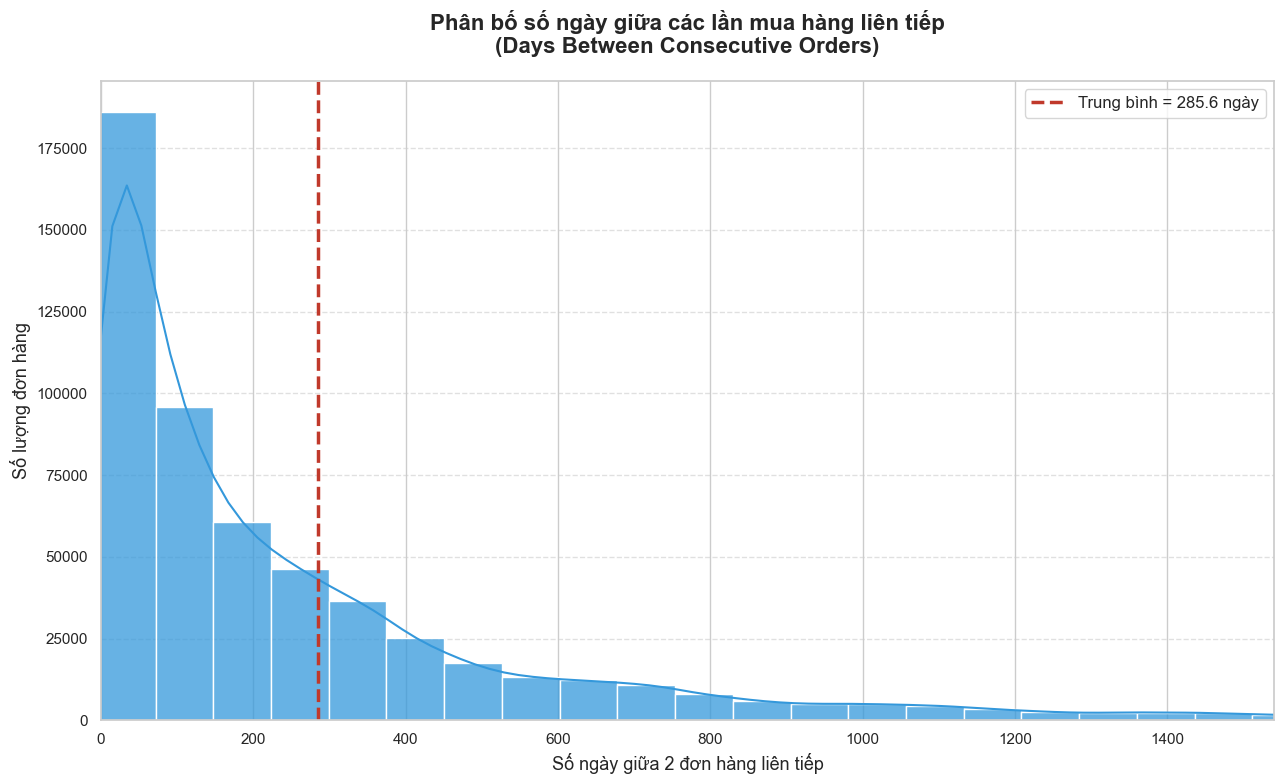

In [5]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 12

plt.figure(figsize=(13, 8))

sns.histplot(df['days_between'].dropna(), bins=50, kde=True, color='#3498db', alpha=0.75)

plt.title(
    'Phân bố số ngày giữa các lần mua hàng liên tiếp\n(Days Between Consecutive Orders)',
    fontsize=16,
    fontweight='bold',
    pad=20
)
plt.xlabel('Số ngày giữa 2 đơn hàng liên tiếp', fontsize=13)
plt.ylabel('Số lượng đơn hàng', fontsize=13)

plt.axvline(
    avg_days,
    color='#c0392b',
    linestyle='--',
    linewidth=2.5,
    label=f'Trung bình = {avg_days:.1f} ngày'
)

plt.legend(frameon=True, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6, axis='y')

plt.xlim(0, df['days_between'].quantile(0.98))
plt.tight_layout()
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10360\1733683069.py:7: SyntaxWarning: invalid escape sequence '\D'
  customers = pd.read_csv("D:\Datathon\data\customers.csv")
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10360\1733683069.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


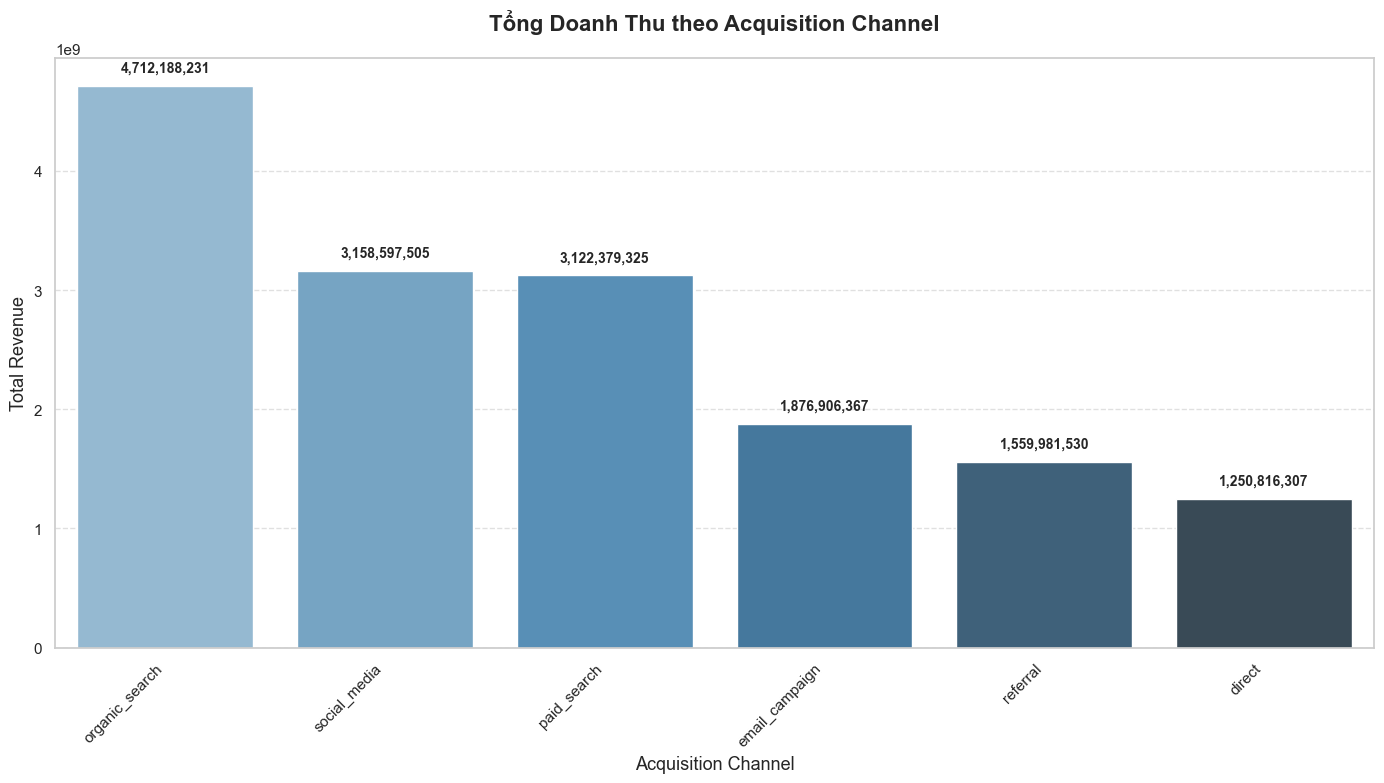

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 12

customers = pd.read_csv("D:\Datathon\data\customers.csv")

df = df.merge(customers, on='customer_id', how='left')

revenue_by_channel = df.groupby('acquisition_channel').agg({
    'payment_value': 'sum',
    'order_id': 'count'
}).reset_index()

revenue_by_channel = revenue_by_channel.rename(columns={
    'payment_value': 'total_revenue',
    'order_id': 'total_orders'
})

revenue_by_channel = revenue_by_channel.sort_values(by='total_revenue', ascending=False)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=revenue_by_channel,
    x='acquisition_channel',
    y='total_revenue',
    color='#2980b9',
    palette='Blues_d'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height() + 0.02 * revenue_by_channel['total_revenue'].max()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Tổng Doanh Thu theo Acquisition Channel', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Acquisition Channel', fontsize=13)
plt.ylabel('Total Revenue', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10360\3729499336.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


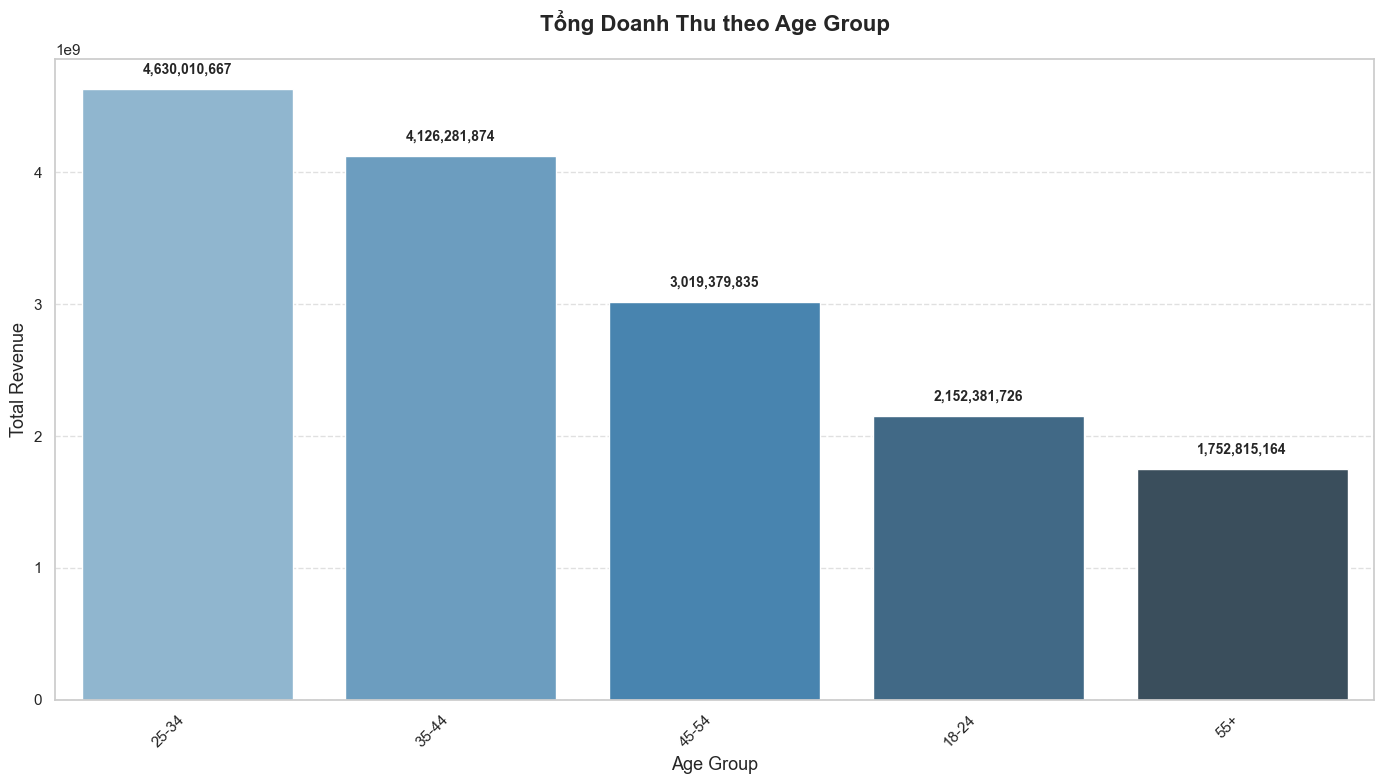

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 12

revenue_by_channel = df.groupby('age_group').agg({
    'payment_value': 'sum',
    'order_id': 'count'
}).reset_index()

revenue_by_channel = revenue_by_channel.rename(columns={
    'payment_value': 'total_revenue',
    'order_id': 'total_orders'
})

revenue_by_channel = revenue_by_channel.sort_values(by='total_revenue', ascending=False)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=revenue_by_channel,
    x='age_group',
    y='total_revenue',
    color='#2980b9',
    palette='Blues_d'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height() + 0.02 * revenue_by_channel['total_revenue'].max()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Tổng Doanh Thu theo Age Group', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Age Group', fontsize=13)
plt.ylabel('Total Revenue', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10360\4231350081.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


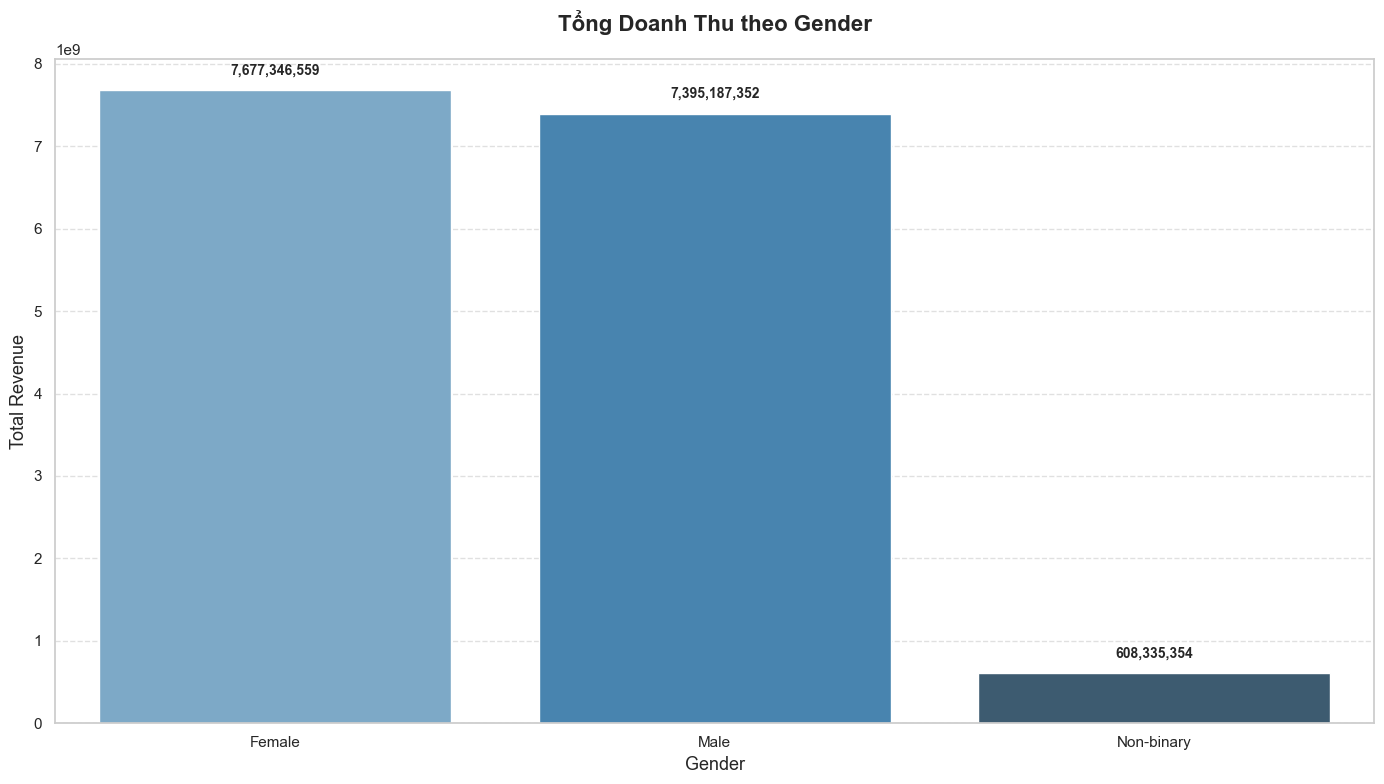

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 12

revenue_by_channel = df.groupby('gender').agg({
    'payment_value': 'sum',
    'order_id': 'count'
}).reset_index()

revenue_by_channel = revenue_by_channel.rename(columns={
    'payment_value': 'total_revenue',
    'order_id': 'total_orders'
})

revenue_by_channel = revenue_by_channel.sort_values(by='total_revenue', ascending=False)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=revenue_by_channel,
    x='gender',
    y='total_revenue',
    color='#2980b9',
    palette='Blues_d'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height() + 0.02 * revenue_by_channel['total_revenue'].max()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Tổng Doanh Thu theo Gender', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Gender', fontsize=13)
plt.ylabel('Total Revenue', fontsize=13)
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.tight_layout()
plt.show()